#  Treinamento (DQN com Experience Replay)

Este notebook demonstra o treinamento de um **Smart Order Router (SOR)** com **DQN + Experience Replay**, usando um ambiente simulado com dois venues de negociação e dados sintéticos de profundidade de livro (LOB).

O fluxo principal é:

1. **Configuração do ambiente** e dependências.
2. **Geração de dados simulados** para os livros de ofertas.
3. **Criação do ambiente multi-venue** para execução de ordens.
4. **Inicialização da rede MoE (Mixture of Experts)** como agente.
5. **Treinamento do agente** via Experience Replay.
6. **Visualização da curva de aprendizado**.
7. **Salvamento do modelo treinado** para uso posterior em avaliação.

O objetivo é minimizar custo de execução, slippage e impacto de mercado ao distribuir a ordem entre diferentes venues de forma inteligente.


In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().resolve()
while not (ROOT_DIR / "src").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent
sys.path.insert(0, str(ROOT_DIR))

OUT_MODELS = ROOT_DIR / "models"
OUT_LOGS   = ROOT_DIR / "logs"
OUT_MODELS.mkdir(parents=True, exist_ok=True)
OUT_LOGS.mkdir(parents=True, exist_ok=True)

print("ROOT_DIR   =", ROOT_DIR)
print("OUT_MODELS =", OUT_MODELS)
print("OUT_LOGS   =", OUT_LOGS)

ROOT_DIR   = /Users/tuerepinto/Documents/repository/tcc-sor-dql-moe
OUT_MODELS = /Users/tuerepinto/Documents/repository/tcc-sor-dql-moe/models
OUT_LOGS   = /Users/tuerepinto/Documents/repository/tcc-sor-dql-moe/logs


In [2]:
import os, sys
print("os module:", os)
print("os file  :", getattr(os, "__file__", None))
print("sys.path[0]:", sys.path[0])

os module: <module 'os' (frozen)>
os file  : /usr/local/Cellar/python@3.12/3.12.12/Frameworks/Python.framework/Versions/3.12/lib/python3.12/os.py
sys.path[0]: /Users/tuerepinto/Documents/repository/tcc-sor-dql-moe


In [3]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.sor_env_numpy import MultiVenueSOREnvNumpy
from src.offline_dataset import df_to_l2_numpy
from src.moe_dqn import MoENetwork
from src.train_agent import train_dqn

plt.style.use("seaborn-v0_8-whitegrid")
torch.set_printoptions(sci_mode=False, precision=4)

In [4]:
steps = 100
np.random.seed(42)

df_b3 = pd.DataFrame({
    'ask_1': np.random.uniform(35.00, 35.10, steps), 'vol_ask_1': np.random.randint(100, 1000, steps),
    'ask_2': np.random.uniform(35.11, 35.20, steps), 'vol_ask_2': np.random.randint(100, 1000, steps),
    'ask_3': np.random.uniform(35.21, 35.30, steps), 'vol_ask_3': np.random.randint(100, 1000, steps),
    'ask_4': np.random.uniform(35.31, 35.40, steps), 'vol_ask_4': np.random.randint(100, 1000, steps),
    'ask_5': np.random.uniform(35.41, 35.50, steps), 'vol_ask_5': np.random.randint(100, 1000, steps),
})

df_base = pd.DataFrame({
    'ask_1': np.random.uniform(34.98, 35.08, steps), 'vol_ask_1': np.random.randint(50, 800, steps),
    'ask_2': np.random.uniform(35.09, 35.18, steps), 'vol_ask_2': np.random.randint(50, 800, steps),
    'ask_3': np.random.uniform(35.19, 35.28, steps), 'vol_ask_3': np.random.randint(50, 800, steps),
    'ask_4': np.random.uniform(35.29, 35.38, steps), 'vol_ask_4': np.random.randint(50, 800, steps),
    'ask_5': np.random.uniform(35.39, 35.48, steps), 'vol_ask_5': np.random.randint(50, 800, steps),
})

print("df_b3:", df_b3.shape, "| df_base:", df_base.shape)

df_b3: (100, 10) | df_base: (100, 10)


In [5]:
TOTAL_ORDER = 5_000
SEED = 42

lob_b3_np = df_to_l2_numpy(df_b3)
lob_base_np = df_to_l2_numpy(df_base)

env = MultiVenueSOREnvNumpy(
    lob_b3=lob_b3_np,
    lob_base=lob_base_np,
    total_inventory=TOTAL_ORDER,
    max_slippage_pct=0.001,
)

s0, info0 = env.reset(seed=42)
print("reset ok | obs:", s0, "| arrival:", env.arrival_price, "| inv_left:", info0["inventory_left"])

reset ok | obs: [  35.037453  674.         35.039845  492.       5000.      ] | arrival: 35.037452697753906 | inv_left: 5000.0


In [6]:
import torch
from src.moe_dqn import MoENetwork
from src.train_agent import train_dqn

agent = MoENetwork(input_dim=5, output_dim=4, num_experts=3)

model_trained, rewards = train_dqn(env, agent, seed=42)

model_path = OUT_MODELS / "moe_dqn_sor_SYNTHETIC.pth"
torch.save(model_trained.state_dict(), model_path)

print("Treino ok | episodes:", len(rewards))
print("Saved model:", model_path, "| exists?", model_path.exists())

Treino ok | episodes: 500
Saved model: /Users/tuerepinto/Documents/repository/tcc-sor-dql-moe/models/moe_dqn_sor_SYNTHETIC.pth | exists? True


In [7]:
DATA_ROOT = ROOT_DIR / "data" / "l2_parquet"

SYMBOLS = ["PETR4", "VALE3", "ITUB4"]
VENUE_B3 = "B3"
VENUE_BASE = "BASE"

TOTAL_ORDER = 10_000
EP_LEN = 500
MAX_SLIPPAGE_PCT = 0.001  # 0.10%

print("DATA_ROOT:", DATA_ROOT)

DATA_ROOT: /Users/tuerepinto/Documents/repository/tcc-sor-dql-moe/data/l2_parquet


In [8]:
from pathlib import Path
from src.offline_dataset import list_available_dates

def safe_list_dates(root: Path, venue: str, symbol: str):
    base = Path(root) / f"venue={venue}" / f"symbol={symbol}"
    if not base.exists():
        return []
    return list_available_dates(root, venue, symbol)

for sym in SYMBOLS:
    d_b3 = safe_list_dates(DATA_ROOT, VENUE_B3, sym)
    d_base = safe_list_dates(DATA_ROOT, VENUE_BASE, sym)
    print(f"{sym}: {VENUE_B3} days={len(d_b3)} | {VENUE_BASE} days={len(d_base)}")

PETR4: B3 days=0 | BASE days=0
VALE3: B3 days=0 | BASE days=0
ITUB4: B3 days=0 | BASE days=0


In [9]:
import src.train_agent as TA

TA.EPISODES = 200
TA.BATCH_SIZE = 64
TA.TARGET_UPDATE_EVERY = 500

print("EPISODES =", TA.EPISODES)

EPISODES = 200


In [10]:
def train_one_symbol(symbol: str, seed: int = 42):
    env = MultiVenueSOREnvNumpy(
        root=str(DATA_ROOT),
        symbol=symbol,
        venue_b3=VENUE_B3,
        venue_base=VENUE_BASE,
        episode_len=EP_LEN,
        total_inventory=TOTAL_ORDER,
        max_slippage_pct=MAX_SLIPPAGE_PCT,
        seed=seed,
    )

    # sanity reset (NÃO usar info0["arrival_price"] no reset)
    s0, info0 = env.reset(seed=seed)
    print(f"\n[{symbol}] reset ok | obs shape={s0.shape} | arrival={env.arrival_price:.4f} | inv_left={info0['inventory_left']:.0f}")

    # sanity step rápido (garante contrato do info do step)
    a = env.action_space.sample()
    _s1, _r, _term, _trunc, info1 = env.step(a)
    required = {
        "inventory_left", "arrival_price",
        "executed_cost", "executed_volume",
        "avg_price", "slippage", "is_valid", "rejection_reason",
        "t", "T",
    }
    missing = required - set(info1.keys())
    if missing:
        raise RuntimeError(f"[{symbol}] Env.step() info incompleto. Faltam: {missing}")

    model = MoENetwork(input_dim=5, output_dim=4, num_experts=3)

    t0 = time.time()
    model_trained, rewards = train_dqn(env, model, seed=seed)
    dt = time.time() - t0

    # salvar modelo
    model_dir = ROOT_DIR / "models"
    model_dir.mkdir(parents=True, exist_ok=True)
    model_path = model_dir / f"moe_dqn_sor_{symbol}_12m.pth"
    torch.save(model_trained.state_dict(), model_path)

    # salvar rewards
    log_dir = ROOT_DIR / "logs"
    log_dir.mkdir(parents=True, exist_ok=True)
    rewards_path = log_dir / f"rewards_{symbol}_12m.parquet"
    pd.DataFrame({"episode": np.arange(len(rewards)), "reward": rewards}).to_parquet(rewards_path, index=False)

    print(f"[{symbol}] treino finalizado em {dt/60:.1f} min")
    print(f"[{symbol}] model -> {model_path}")
    print(f"[{symbol}] rewards -> {rewards_path}")

    return model_trained, rewards

In [11]:
results = {}  # symbol -> rewards
models = {}   # symbol -> model (em memória)

for sym in SYMBOLS:
    # fallback to synthetic LOBs (no per-symbol parquet available)
    print(f"[{sym}] training using synthetic LOBs")
    env_sym = MultiVenueSOREnvNumpy(
        lob_b3=lob_b3_np,
        lob_base=lob_base_np,
        total_inventory=TOTAL_ORDER,
        max_slippage_pct=MAX_SLIPPAGE_PCT,
    )
    m = MoENetwork(input_dim=5, output_dim=4, num_experts=3)
    m, r = train_dqn(env_sym, m, seed=SEED)
    models[sym] = m
    results[sym] = r

[PETR4] training using synthetic LOBs
[VALE3] training using synthetic LOBs
[ITUB4] training using synthetic LOBs


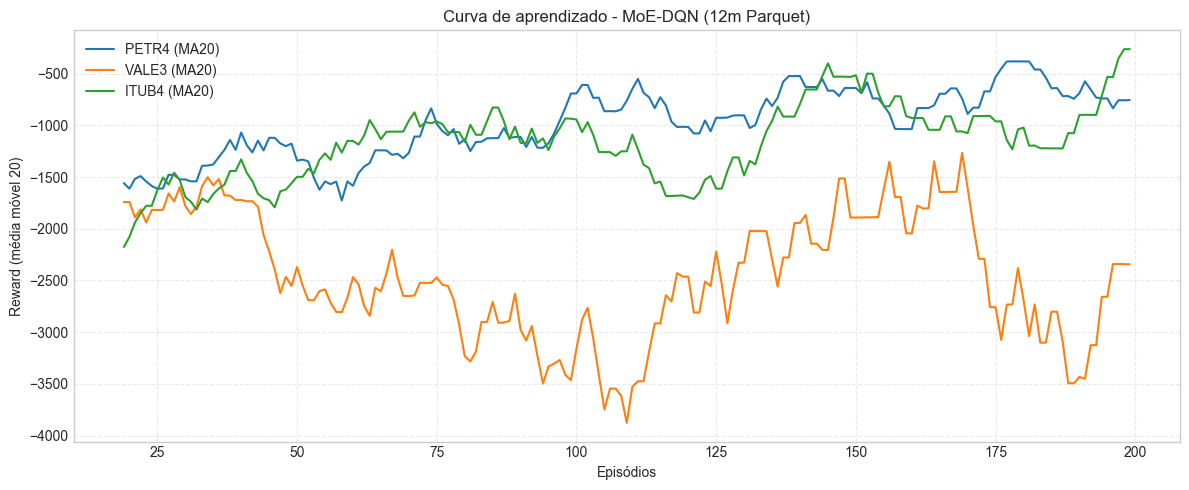

In [12]:
plt.figure(figsize=(12, 5))

for sym, rewards in results.items():
    s = pd.Series(rewards)
    plt.plot(s.rolling(20).mean(), label=f"{sym} (MA20)")

plt.title("Curva de aprendizado - MoE-DQN (12m Parquet)")
plt.xlabel("Episódios")
plt.ylabel("Reward (média móvel 20)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# 1. Instanciando o Ambiente (Ordem de 5.000 ações)
lob_b3_np = df_to_l2_numpy(df_b3)
lob_base_np = df_to_l2_numpy(df_base)

env = MultiVenueSOREnvNumpy(lob_b3=lob_b3_np, lob_base=lob_base_np, total_inventory=5000)

# 2. Instanciando a Rede Neural (Cérebro MoE)
agente_moe = MoENetwork(input_dim=5, output_dim=4, num_experts=3)

# 3. Executando o Loop de Treinamento
print("Iniciando o treinamento via Experience Replay. Isso pode levar alguns segundos...")

# A função train_dqn vai rodar os episódios e retornar o modelo atualizado e o histórico
modelo_treinado, historico_recompensas = train_dqn(env, agente_moe)

print("\nTreinamento finalizado com sucesso!")

Iniciando o treinamento via Experience Replay. Isso pode levar alguns segundos...

Treinamento finalizado com sucesso!


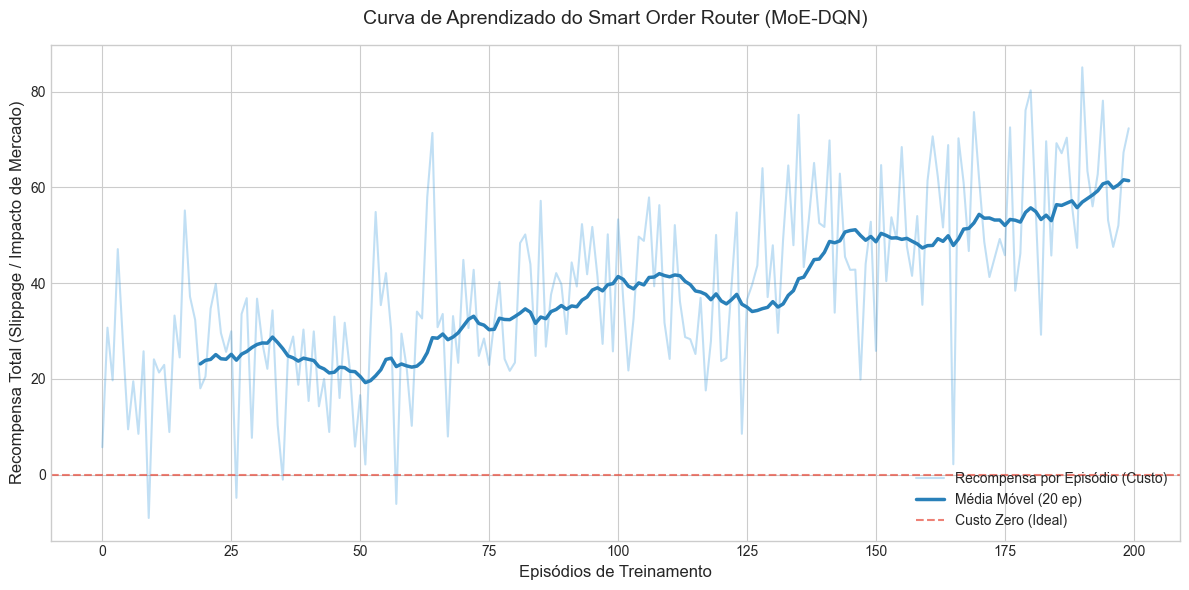

In [14]:
def plot_learning_curve(recompensas, window_size=20):
    plt.figure(figsize=(12, 6))

    # Recompensas brutas (linha clara)
    plt.plot(recompensas, color='#3498db', alpha=0.3, label='Recompensa por Episódio (Custo)')

    # Média Móvel (linha escura)
    if len(recompensas) >= window_size:
        moving_avg = np.convolve(recompensas, np.ones(window_size)/window_size, mode='valid')
        plt.plot(range(window_size-1, len(recompensas)), moving_avg, 
                 color='#2980b9', linewidth=2.5, label=f'Média Móvel ({window_size} ep)')

    plt.title('Curva de Aprendizado do Smart Order Router (MoE-DQN)', fontsize=14, pad=15)
    plt.xlabel('Episódios de Treinamento', fontsize=12)
    plt.ylabel('Recompensa Total (Slippage / Impacto de Mercado)', fontsize=12)

    # Linha de base (Custo Zero)
    plt.axhline(y=0, color='#e74c3c', linestyle='--', alpha=0.7, label='Custo Zero (Ideal)')

    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# Gerando o gráfico com os dados do treinamento
plot_learning_curve(historico_recompensas)

In [16]:
# salvar
model_path = ROOT_DIR / "models" / f"moe_dqn_sor.pth"
model_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model_trained.state_dict(), model_path)
print("Saved:", model_path)

Saved: /Users/tuerepinto/Documents/repository/tcc-sor-dql-moe/models/moe_dqn_sor.pth
